# Fraud Detection

## Importation 

In [ ]:
# Pour les manipulations et entrainements
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import kruskal, chi2_contingency, chi2
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, PredefinedSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,IsolationForest, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, confusion_matrix, recall_score, precision_score, accuracy_score, log_loss, brier_score_loss, precision_recall_curve,auc, f1_score
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import dataframe_image as dfi

# Pour resampling
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss, CondensedNearestNeighbour
from imblearn.combine import SMOTEENN
import time

# Pour stylisation pas obligatoire
from selenium import webdriver
from selenium.webdriver.firefox.options import Options 
from selenium.webdriver.common.by import By
from webdriver_manager.firefox import GeckoDriverManager
from selenium.webdriver.firefox.service import Service
import time
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# Importation de la base initiale
df = pd.read_csv('creditcard.csv')
X=df.iloc[:,:30]
y=df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y, random_state=2026)
test_set = pd.concat([X_test,y_test], axis=1)
train_set = pd.concat([X_train,y_train], axis=1)
train_set

# Recupe est un dictionnaire contenant entrainement de tous nos modeles cela evite de reexecuter la boucle longue
# Recupe =  joblib.load('Recupe.joblib')
# joblib.dump(Recupe, 'Recupe.joblib')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
123040,76785.0,1.206719,0.187959,0.253196,0.725545,-0.502731,-1.092569,0.039633,-0.142917,0.209364,...,-0.285978,-0.940466,0.121418,0.314142,0.166627,0.095695,-0.035600,0.032662,26.99,0
85051,60576.0,1.157839,0.335348,0.215882,1.224899,-0.302738,-1.244180,0.462501,-0.337945,-0.209779,...,0.019366,0.026715,-0.092240,0.718571,0.681134,-0.383227,-0.001315,0.027495,43.21,0
91579,63534.0,-0.344617,0.629967,1.270264,0.884281,0.186630,-0.561237,0.512775,0.056462,-0.733915,...,0.186115,0.389151,-0.106431,0.313358,0.029185,-0.299746,0.046470,0.039337,29.28,0
121327,76152.0,-1.372935,1.119068,0.255979,-0.224847,0.486614,-0.536860,1.270043,-0.417007,-0.123625,...,-0.093559,0.131447,0.023743,-0.399999,-0.033880,0.292130,-0.028912,0.356525,66.30,0
44601,42014.0,-3.888588,-3.480963,0.189068,-1.551981,1.861539,-0.603172,-0.235471,0.876005,0.515817,...,0.615757,0.311002,0.339525,-0.898667,0.605742,0.100635,-0.094075,-0.508209,288.08,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259760,159260.0,2.189757,-1.663723,0.040048,-1.581248,-1.853630,0.032107,-1.855467,0.116155,-0.888309,...,-0.100279,0.251960,0.279721,-0.348462,-0.518499,-0.248406,0.064736,-0.039845,24.90,0
215120,139946.0,-1.872545,1.275747,-0.082502,-0.854989,0.115745,-1.180208,0.643852,0.626921,-0.323394,...,-0.147327,-0.664600,-0.311368,-0.136679,0.864649,-0.056830,-0.331870,-0.155694,49.96,0
186930,127315.0,-1.858829,2.204040,-2.975262,0.136164,0.070957,-1.437755,-0.389560,1.402087,-0.847359,...,0.363215,0.816450,0.060330,-0.524513,-0.165745,-0.158815,-0.376681,-0.275510,1.00,0
219269,141661.0,1.978124,0.050185,-1.258583,0.355158,0.175904,-0.421169,-0.201037,0.050909,0.428910,...,-0.508106,-1.448303,0.548825,0.542134,-0.689770,-0.120944,-0.041045,-0.022207,2.87,0


## Analyses rapides

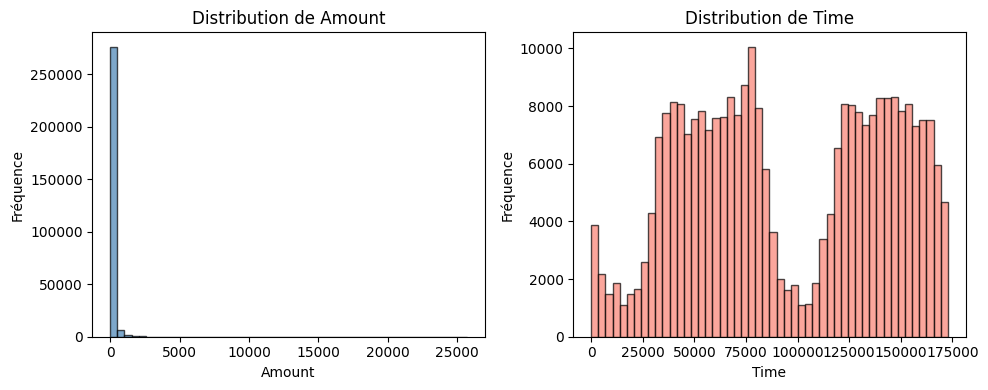

In [2]:
plt.figure(figsize=(10, 4))

# 1) Distribution de Amount
plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Amount')
plt.ylabel('Fréquence')
plt.title('Distribution de Amount')

# 2) Distribution de Time
plt.subplot(1, 2, 2)
plt.hist(df['Time'], bins=50, color='salmon', edgecolor='black', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Fréquence')
plt.title('Distribution de Time')

plt.tight_layout()
plt.show()


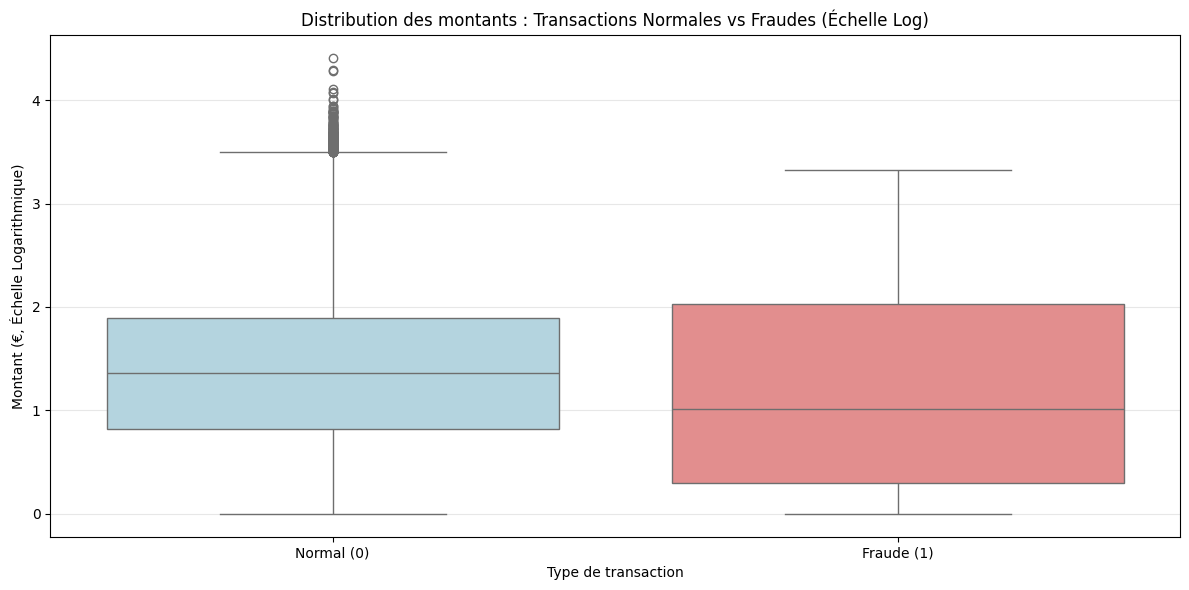

In [ ]:
plt.figure(figsize=(12, 6))

df['Class_label'] = df['Class'].map({0: 'Normal (0)', 1: 'Fraude (1)'})
df['Amount_log'] = np.log10(df['Amount'] + 1)

# Boxplot
sns.boxplot(x='Class_label', y='Amount_log', data=df, palette=['lightblue', 'lightcoral'])

plt.xlabel('Type de transaction')
plt.ylabel('Montant (€, Échelle Logarithmique)')
plt.title('Distribution des montants : Transactions Normales vs Fraudes (Échelle Log)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Nettoyage
df.drop(['Class_label', 'Amount_log'], axis=1, inplace=True)

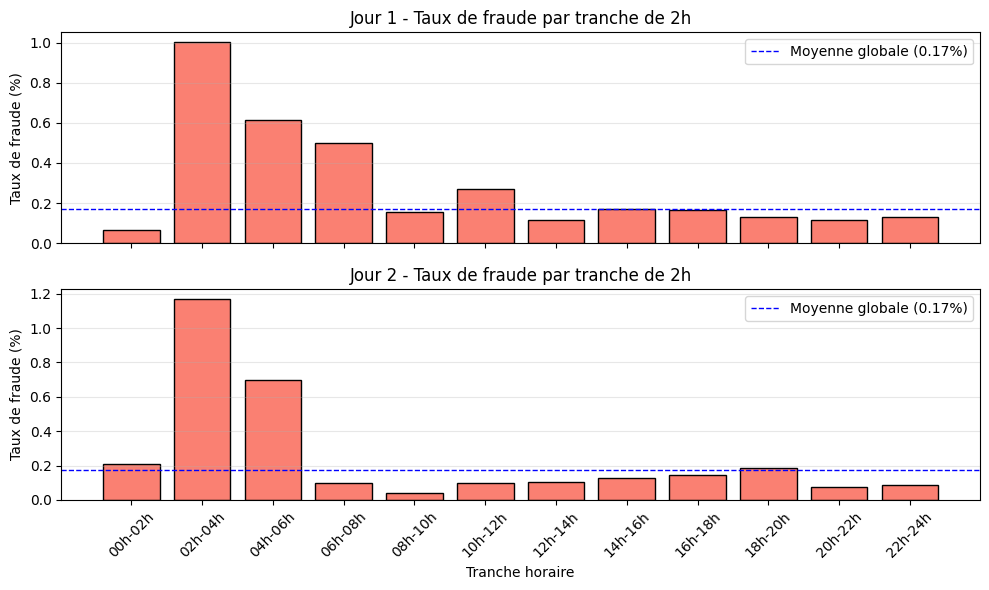

In [4]:
# Time en heures et jour (0,1,2,…)
df['Time_hours'] = df['Time'] / 3600
df['Day'] = df['Time_hours'] // 24

# Bins de 2h sur une journée
bins_2h = np.arange(0, 24 + 2, 2)
labels_2h = [f"{int(b):02d}h-{int(b+2):02d}h" for b in bins_2h[:-1]]

# Fonction pour calculer le taux de fraude par tranche de 2h pour un jour donné
def fraud_rate_by_2h(day):
    sub = df[df['Day'] == day].copy()
    sub['Hour'] = sub['Time_hours'] % 24
    sub['bin_2h'] = pd.cut(sub['Hour'], bins=bins_2h, labels=labels_2h, right=False)
    grp = sub.groupby('bin_2h')['Class'].mean() * 100   # taux en %
    return grp

# Taux global de fraude
global_rate = df['Class'].mean() * 100

rate_day1 = fraud_rate_by_2h(0)
rate_day2 = fraud_rate_by_2h(1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for ax, rates, title in zip(
    axes,
    [rate_day1, rate_day2],
    ["Jour 1 - Taux de fraude par tranche de 2h",
     "Jour 2 - Taux de fraude par tranche de 2h"]
):
    ax.bar(range(len(rates)), rates.values, color='salmon', edgecolor='black')
    ax.axhline(global_rate, color='blue', linestyle='--', linewidth=1,
               label=f"Moyenne globale ({global_rate:.2f}%)")
    ax.set_ylabel("Taux de fraude (%)")
    ax.set_title(title)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates.index, rotation=45)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.xlabel("Tranche horaire")
plt.tight_layout()
plt.show()


In [5]:
# Corrélation Pearson d'Amount avec toutes les variables numériques
num_cols = df.select_dtypes(include=['number']).columns

corr_amount = df[num_cols].corr(method='pearson')['Amount'].sort_values(ascending=False)
print(corr_amount)


Amount        1.000000
V7            0.397311
V20           0.339403
V6            0.215981
V21           0.105999
V4            0.098732
V18           0.035650
V14           0.033751
V27           0.028825
V28           0.010258
V17           0.007309
Class         0.005632
V13           0.005293
V24           0.005146
V11           0.000104
V15          -0.002986
V26          -0.003208
V16          -0.003910
Day          -0.008485
V12          -0.009542
Time_hours   -0.010596
Time         -0.010596
V9           -0.044246
V25          -0.047837
V19          -0.056151
V22          -0.064801
V10          -0.101502
V8           -0.103079
V23          -0.112633
V3           -0.210880
V1           -0.227709
V5           -0.386356
V2           -0.531409
Name: Amount, dtype: float64


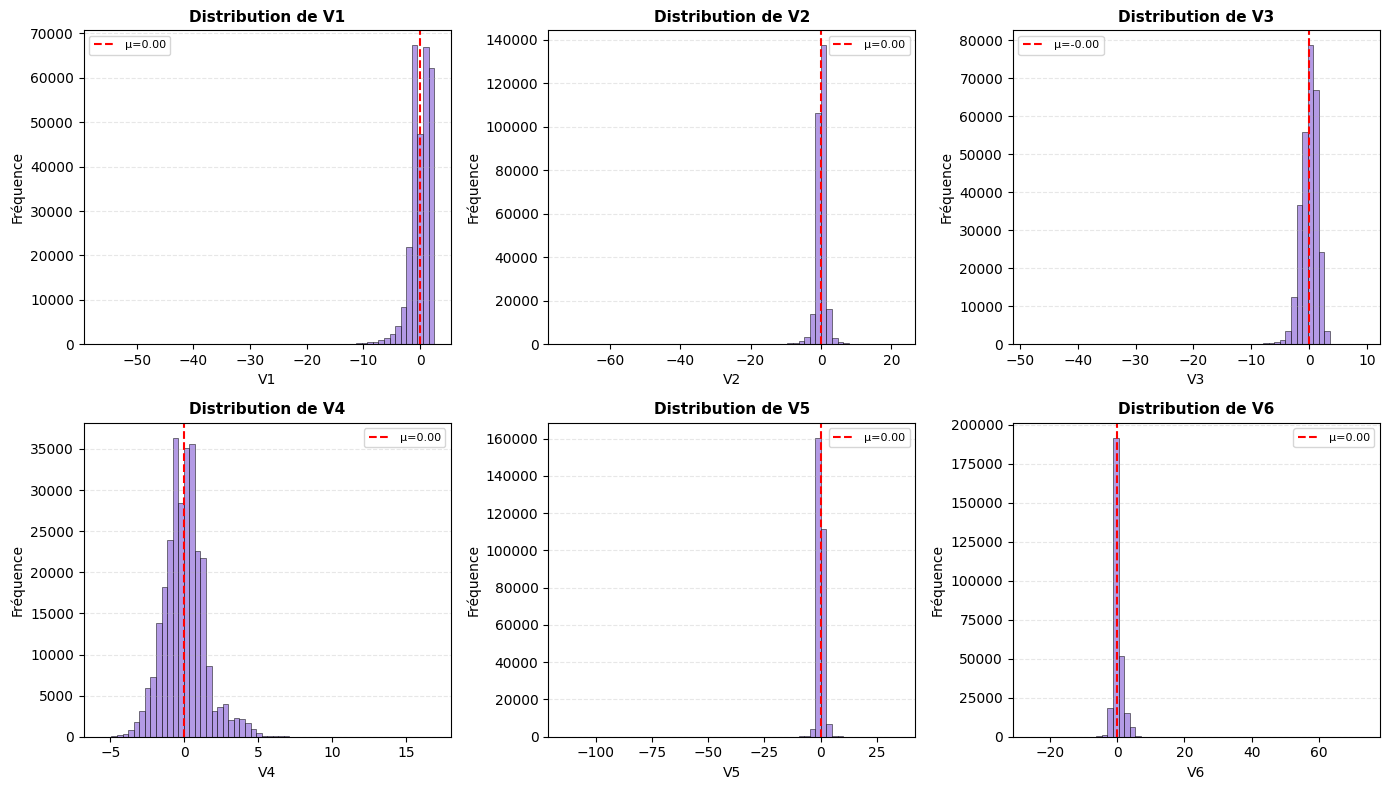

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

pca_vars = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']

for i, var in enumerate(pca_vars):
    axes[i].hist(df[var], bins=60, color='mediumpurple', edgecolor='black', 
                alpha=0.7, linewidth=0.5)
    axes[i].set_title(f'Distribution de {var}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Fréquence')
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Ajouter des statistiques
    mean_val = df[var].mean()
    std_val = df[var].std()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                   label=f'μ={mean_val:.2f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# 1. Corrélation de Spearman entre Amount et V2
spearman_corr = df['Amount'].corr(df['V2'], method='spearman')

# 2. Calcul du VIF
# On sélectionne les variables V1 à V28 et Amount
features = [f'V{i}' for i in range(1, 29)] + ['Amount']
X = df[features].dropna()

# Le calcul du VIF nécessite l'ajout d'une constante (intercept)
X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i+1) 
                   for i in range(len(X.columns))]

print(vif_data.sort_values(by='VIF', ascending=False))

   Variable        VIF
28   Amount  12.115746
1        V2   4.421432
6        V7   2.912546
4        V5   2.808531
19      V20   2.395669
0        V1   1.628216
5        V6   1.565174
2        V3   1.538794
22      V23   1.153701
20      V21   1.136130
7        V8   1.128733
9       V10   1.124825
3        V4   1.118104
21      V22   1.050876
18      V19   1.038200
24      V25   1.027725
8        V9   1.023719
17      V18   1.015398
13      V14   1.013802
26      V27   1.010067
27      V28   1.001275
11      V12   1.001103
16      V17   1.000647
12      V13   1.000339
23      V24   1.000321
15      V16   1.000185
25      V26   1.000125
14      V15   1.000108
10      V11   1.000000


In [8]:
num_vars = df.select_dtypes(include=['number']).columns
num_vars = [c for c in num_vars if c != 'Class']

results_kw = []

for var in num_vars:
    group_normal = df.loc[df['Class'] == 0, var]
    group_fraud  = df.loc[df['Class'] == 1, var]

    stat, p_value = kruskal(group_normal, group_fraud)
    results_kw.append({
        'Variable': var,
        'Statistique_KW': stat,
        'p_value': p_value
    })

kw_df = pd.DataFrame(results_kw).sort_values('Statistique_KW', ascending=False)
print(kw_df)

      Variable  Statistique_KW        p_value
14         V14     1189.037432  1.471567e-260
4           V4     1132.020912  3.625871e-248
12         V12     1125.737230  8.415949e-247
11         V11     1030.194668  4.910549e-226
10         V10     1010.450247  9.611047e-222
3           V3     1000.787198  1.211038e-219
2           V2      742.576282  1.650425e-163
16         V16      710.201992  1.808159e-156
9           V9      697.811931  8.943658e-154
7           V7      664.638374  1.464223e-146
17         V17      559.815752  9.219324e-124
1           V1      512.580648  1.740774e-113
6           V6      420.178941   2.230990e-93
21         V21      357.756128   8.673310e-80
18         V18      346.345027   2.648948e-77
5           V5      258.851673   3.053698e-58
27         V27      228.279190   1.414583e-51
8           V8      146.839019   8.509863e-34
19         V19      144.777687   2.401952e-33
20         V20      132.560599   1.128101e-30
28         V28      118.723941   1

In [9]:
data = df.drop(columns=['Class'])

# On ne garde que les variables numériques
num_cols = data.select_dtypes(include=['number']).columns

outlier_results = []

for col in num_cols:
    if col == 'Time':
        continue

    s = data[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((s < lower) | (s > upper)).sum()
    percentage = n_outliers / len(s) * 100

    outlier_results.append({'Variable': col, 'Pourcentage': round(percentage, 2)})

df_table2 = pd.DataFrame(outlier_results).sort_values('Pourcentage', ascending=False)
print(df_table2)


      Variable  Pourcentage
26         V27        13.75
28      Amount        11.20
27         V28        10.65
19         V20         9.75
7           V8         8.47
5           V6         8.06
22         V23         6.51
11         V12         5.39
20         V21         5.09
13         V14         4.97
1           V2         4.75
4           V5         4.32
3           V4         3.91
18         V19         3.58
9          V10         3.33
6           V7         3.14
8           V9         2.91
15         V16         2.87
17         V18         2.64
16         V17         2.61
0           V1         2.48
25         V26         1.96
24         V25         1.88
23         V24         1.68
2           V3         1.18
12         V13         1.18
14         V15         1.02
21         V22         0.46
10         V11         0.27
29  Time_hours         0.00
30         Day         0.00


In [10]:
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

# Variables analysées
v_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']
X = df[v_cols].values

# 1) Z-Score classique
z_scores = np.abs(stats.zscore(df[v_cols]))
outliers_zscore = (z_scores > 3).any(axis=1)
df['outlier_zscore'] = outliers_zscore

# 2) Z-Score modifié (MAD)
def modified_zscore(data):
    median = np.median(data, axis=0)
    mad = np.median(np.abs(data - median), axis=0)
    return 0.6745 * (data - median) / (mad + 1e-10)

modified_z = np.abs(modified_zscore(df[v_cols].values))
outliers_mad = (modified_z > 3.5).any(axis=1)
df['outlier_mad'] = outliers_mad

# 3) Isolation Forest
iso = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
outliers_iso = iso.fit_predict(X) == -1
df['outlier_iso'] = outliers_iso

# 4) Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
outliers_lof = lof.fit_predict(X) == -1
df['outlier_lof'] = outliers_lof

# 5) Elliptic Envelope (sous-ensemble de variables stables)
vars_stable = ['V1', 'V2', 'V3', 'V4', 'V5',
               'V9', 'V10', 'V11', 'V14',
               'V16', 'V17', 'V18', 'Amount']
X_stable = df[vars_stable].values

envelope = EllipticEnvelope(contamination=0.1, random_state=42)
outliers_envelope = envelope.fit_predict(X_stable) == -1
df['outlier_envelope'] = outliers_envelope

# Synthèse des méthodes
methods = {
    'Z-Score': 'outlier_zscore',
    'MAD': 'outlier_mad',
    'Isolation Forest': 'outlier_iso',
    'LOF': 'outlier_lof',
    'Elliptic Envelope': 'outlier_envelope'
}

results = []
total_fraudes = df['Class'].sum()
taux_fraude_general = df['Class'].mean() * 100

for name, col in methods.items():
    n_out = df[col].sum()
    pct_out = n_out / len(df) * 100
    fraudes_cap = df.loc[df[col], 'Class'].sum()
    pct_fraudes_cap = fraudes_cap / total_fraudes * 100
    taux_fraude_out = df.loc[df[col], 'Class'].mean() * 100
    enrichissement = taux_fraude_out / taux_fraude_general if taux_fraude_general > 0 else np.nan

    results.append({
        'Méthode': name,
        'N_Outliers': n_out,
        '%_Outliers': pct_out,
        'Fraudes_Capturées': fraudes_cap,
        '%_Fraudes_Capturées': pct_fraudes_cap,
        'Enrichissement': enrichissement
    })

summary_df = pd.DataFrame(results).sort_values('%_Fraudes_Capturées', ascending=False)
print(summary_df.round(3))


             Méthode  N_Outliers  %_Outliers  Fraudes_Capturées  \
1                MAD      110265      38.716                469   
0            Z-Score       37816      13.278                444   
2   Isolation Forest       28481      10.000                434   
4  Elliptic Envelope       28481      10.000                401   
3                LOF       28481      10.000                201   

   %_Fraudes_Capturées  Enrichissement  
1               95.325           2.462  
0               90.244           6.797  
2               88.211           8.821  
4               81.504           8.150  
3               40.854           4.085  


## Preparation

### Création des bases (24 min)

In [ ]:
# on Définit les ratios souhaités
ratios = {
    '05_95': 5/95,      # 5% minorité, 95% majorité
    '10_90': 1/9,       # 10% minorité, 90% majorité
    '20_80': 2/8        # 20% minorité, 80% majorité 
}

# on Créer le dictionnaire avec les bases rééchantillonnées
bases = {}
for nom, ratio in ratios.items():
    print("Processing ratio:", nom)
    # RandomOverSampler
    t0 = time.perf_counter()
    ros = RandomOverSampler(sampling_strategy=ratio, random_state=2026)
    X_res, y_res = ros.fit_resample(X_train, y_train)
    print("RandomOverSampler duration:", time.perf_counter() - t0)
    bases[f'randomoversampling_{nom}'] = {'X': X_res, 'y': y_res}
    
    # SMOTE
    t0 = time.perf_counter()
    smote = SMOTE(sampling_strategy=ratio, random_state=2026)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    print("SMOTE duration:", time.perf_counter() - t0)
    bases[f'smote_{nom}'] = {'X': X_res, 'y': y_res}
    
    # ADASYN
    t0 = time.perf_counter()
    adasyn = ADASYN(sampling_strategy=ratio, random_state=2026)
    X_res, y_res = adasyn.fit_resample(X_train, y_train)
    print("ADASYN duration:", time.perf_counter() - t0)
    bases[f'adasyn_{nom}'] = {'X': X_res, 'y': y_res}
    
    # BorderlineSMOTE
    t0 = time.perf_counter()
    bsmote = BorderlineSMOTE(sampling_strategy=ratio, random_state=2026)
    X_res, y_res = bsmote.fit_resample(X_train, y_train)
    print("BorderlineSMOTE duration:", time.perf_counter() - t0)
    bases[f'borderlinesmote_{nom}'] = {'X': X_res, 'y': y_res}
    
    # SVMSMOTE
    t0 = time.perf_counter()
    svmsmote = SVMSMOTE(sampling_strategy=ratio, random_state=2026)
    X_res, y_res = svmsmote.fit_resample(X_train, y_train)
    print("SVMSMOTE duration:", time.perf_counter() - t0)
    bases[f'svmsmote_{nom}'] = {'X': X_res, 'y': y_res}
    
    # RandomUnderSampler
    t0 = time.perf_counter()
    rus = RandomUnderSampler(sampling_strategy=ratio, random_state=2026)
    X_res, y_res = rus.fit_resample(X_train, y_train)
    print("RandomUnderSampler duration:", time.perf_counter() - t0)
    bases[f'randomundersampling_{nom}'] = {'X': X_res, 'y': y_res}
    
    # NearMiss
    t0 = time.perf_counter()
    nm = NearMiss(sampling_strategy=ratio, version=1)
    X_res, y_res = nm.fit_resample(X_train, y_train)
    print("NearMiss duration:", time.perf_counter() - t0)
    bases[f'nearmiss_{nom}'] = {'X': X_res, 'y': y_res}
    
    # SMOTEENN (hybride)
    t0 = time.perf_counter()
    smoteenn = SMOTEENN(sampling_strategy=ratio, random_state=2026)
    X_res, y_res = smoteenn.fit_resample(X_train, y_train)
    print("SMOTEENN duration:", time.perf_counter() - t0)
    bases[f'smoteenn_{nom}'] = {'X': X_res, 'y': y_res}


cnn = CondensedNearestNeighbour(random_state=2026)
X_res, y_res = cnn.fit_resample(X_train, y_train)
bases['cnn'] = {'X': X_res, 'y': y_res}

Processing ratio: 05_95
RandomOverSampler duration: 0.07714820001274347
SMOTE duration: 3.0885855997912586
ADASYN duration: 0.2275225999765098
BorderlineSMOTE duration: 0.2564765000715852
SVMSMOTE duration: 6.473766500130296
RandomUnderSampler duration: 0.03274230007082224
NearMiss duration: 0.37060080002993345
SMOTEENN duration: 67.74289399990812
Processing ratio: 10_90
RandomOverSampler duration: 0.06739630037918687
SMOTE duration: 0.1171909999102354
ADASYN duration: 0.2634240002371371
BorderlineSMOTE duration: 0.28472490003332496
SVMSMOTE duration: 5.516126099973917
RandomUnderSampler duration: 0.034709200263023376
NearMiss duration: 0.34309740038588643
SMOTEENN duration: 78.90116340015084
Processing ratio: 20_80
RandomOverSampler duration: 0.08192520029842854
SMOTE duration: 0.16304479958489537
ADASYN duration: 0.28375149983912706
BorderlineSMOTE duration: 0.2878359998576343
SVMSMOTE duration: 6.055678999982774
RandomUnderSampler duration: 0.030331300105899572
NearMiss duration: 0.

In [3]:
bases2 = {}
for nom, data in bases.items():
    X = data['X']
    y = data['y']
    b = X.copy()
    b['Class'] = y.values
    bases2[nom] = b

### Fonction de discrétisation (arbre de décision)

In [ ]:
# Fonction pour discrétiser via arbres de decision (CART)
def create_class_variable_train(data, var_continuous, target, n_classes=4, new_var_name=None, verbose=True):  
    if new_var_name is None:
        new_var_name = var_continuous

    subset = data[[var_continuous, target]].dropna().copy()
    subset[target] = subset[target].astype(float)

    X = subset[[var_continuous]]
    y = subset[target]
    tree = DecisionTreeClassifier(criterion='entropy', max_leaf_nodes=n_classes)
    tree.fit(X, y)

    thresholds = tree.tree_.threshold[tree.tree_.threshold != -2]
    bins = np.sort(thresholds)
    bins = np.concatenate(([X[var_continuous].min() - 1], bins, [X[var_continuous].max() + 1]))

    # Application sur le train
    data[new_var_name] = pd.cut(data[var_continuous], bins=bins, labels=False).astype('Int64')

    summary = (
        data.groupby(new_var_name)
        .agg(
            min_value=(var_continuous, 'min'),
            max_value=(var_continuous, 'max'),
            n_obs=(var_continuous, 'count'),
            target_mean=(target, 'mean')
        )
        .reset_index()
    )

    prev = summary['target_mean'].shift(1)
    curr = summary['target_mean']
    summary['taux_montant'] = (curr - prev) / prev
    summary['taux_descendant'] = (prev - curr) / curr
    summary[['taux_montant', 'taux_descendant']] = summary[['taux_montant', 'taux_descendant']].fillna(0)

    if verbose:
        print(f"\n--- Résumé (train) pour {var_continuous} ({n_classes} classes) ---")
        print(summary.to_string(index=False))

    return summary, bins

### Fonction préparation des bases pour entrainement

In [ ]:
# Creation des bases pour entrainement
def train1(train,test,discret = False):

    # Determination des bases pour la suite d'entrainement, calibration (donc validation en soit) et de test
    X_test = test.iloc[:, :-1]
    y_test = test.iloc[:, 30]

    X_train, X_vali = train_test_split(
    train,        
    test_size=0.25, 
    stratify=train['Class'], 
    random_state=666
    )

    # Application de la discretisation si demandé
    if discret:
        for i in ["Time","Amount"]:
            a, b = create_class_variable_train(X_train, i, "Class", n_classes=2, new_var_name=None, verbose=False)
            b[0] = -100000000000000000000
            b[-1] = 100000000000000000000
            X_train[i] = np.where(X_train[i] == 0, 1, 0)
            X_vali[i] = pd.cut(X_vali[i], bins=b, labels=False).astype('Int64')
            X_vali[i] = np.where(X_vali[i] == 0, 1, 0)
            X_test[i] = pd.cut(X_test[i], bins=b, labels=False).astype('Int64')
            X_test[i] = np.where(X_test[i] == 0, 1, 0)

    y_train = X_train.iloc[:, 30]
    X_train= X_train.iloc[:, :-1]
  
    y_vali = X_vali.iloc[:, 30]
    X_vali= X_vali.iloc[:, :-1]

    # On va calibrer nos modeles via l'echantillon de validation donc on doit préciser quand c'est train ou vali
    X_combined = pd.concat([X_train, X_vali], axis=0)
    y_combined = pd.concat([y_train, y_vali], axis=0)
    split_index = [-1] * len(X_train) + [0] * len(X_vali)
    splito = PredefinedSplit(test_fold=split_index)

    # Pour prendre en compte la classe minoritaire dans nos modeles apres
    ratio_neg_pos = (y_train == 0).sum() / (y_train == 1).sum()

    return splito,ratio_neg_pos,X_combined,y_combined,X_test,y_test

### Fonction d'entrainement des modèles + prédictions sur test

In [ ]:
# Entrainement des modèles
def train2(splito,ratio_neg_pos,X_combined,y_combined,X_test,y_test,typebase):

    # Determination de notre grille de reche d'hyperparametres pr l'entrainement après la
    grille_modele = {
        'LogisticRegression': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=666,))
            ]),
            'params': {
                'clf__C': [0.01, 0.1, 1, 10], 
                'clf__penalty': ['l1', 'l2']
            }
        },
        'RandomForest': {
            'model': Pipeline([
                ('clf', RandomForestClassifier(
                    class_weight='balanced', 
                    n_jobs=-1,          
                    max_samples=0.5,   
                    random_state=666,
                    criterion="entropy"
                ))
            ]),
            'params': {
                'clf__n_estimators': [50, 100],  
                'clf__max_depth': [10, 15],      
                'clf__min_samples_leaf': [2, 5], 
                'clf__max_features': ['sqrt', 0.5] 
            }
        },
        'NeuralNet': {
            'model': Pipeline([
                ('scaler', StandardScaler()), 
                ('clf', MLPClassifier(
                    random_state=666, 
                    max_iter=500,     
                    early_stopping=True, 
                    validation_fraction=0.1, 
                    n_iter_no_change=10   
                ))
            ]),
            'params': {
                'clf__hidden_layer_sizes': [(50,), (100,), (100, 50)],
                'clf__activation': ['relu', 'tanh'],
                'clf__alpha': [0.0001, 0.05],
                'clf__learning_rate_init': [0.001, 0.01]
            }
        },
        'AdaBoost': {
            'model': Pipeline([
                ('clf', AdaBoostClassifier(
                    estimator=DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
                    random_state=666
                ))
            ]),
            'params': {
                'clf__n_estimators': [50, 100, 200],
                'clf__learning_rate': [0.1, 0.5, 1.0] 
            }
        },
        'XGBoost': {
            'model': XGBClassifier(
                scale_pos_weight=ratio_neg_pos,
                eval_metric='logloss',
                tree_method='hist', 
                n_jobs=-1,
                random_state=666,
                early_stopping_rounds=10 
            ),
            'params': {
                'learning_rate': [0.05, 0.1],
                'n_estimators': [500], 
                'max_depth': [3, 6],
                'min_child_weight': [1, 3]
            }
        }
    }

    # Entrainement des modèles
    modelo = {}
    for name, config in grille_modele.items():
        print(f"Entrainement {name}")
        fit_params = {}
        if name == 'XGBoost':
            fit_params = {
                'eval_set': [(X_vali, y_vali)],
                'verbose': False
            } # c pr l'early stop si on a pas d amelioration sinn ça dur trop longtemps 
        search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=splito, 
            scoring='average_precision',
            n_jobs=-1
        )
        search.fit(X_combined, y_combined, **fit_params)
        modelo[name] = search.best_estimator_

    # Prédictions des modeles
    preds = {}
    preds2 = {}
    for name, model in modelo.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        y_prob2 = model.predict_proba(X_vali)[:, 1]
        df_model = pd.DataFrame({
            'y_true': y_test.values,
            'y_pred_prob': y_prob      
        })
        df_model2 = pd.DataFrame({
            "y_true": y_vali.values,
            "y_pred_prob": y_prob2        
        })
        preds[name+"_"+typebase] = df_model
        preds2[name+"_"+typebase] = df_model2

    return modelo, preds, preds2

### Fonctions de visualisation

In [ ]:

def graph_defaut_decile(df, var_prob, var_ytrue, n_groups=10):
    df_sorted = df.sort_values(var_prob, ascending=False).reset_index(drop=True)
    df_sorted['nb'] = range(1, len(df_sorted) + 1)
    df_sorted['groupe'] = pd.qcut(df_sorted['nb'], n_groups, labels=False)

    taux_defaut_groupe = (
        df_sorted.groupby('groupe')[var_ytrue]
        .mean()
        .reset_index()
    )

    plt.figure()
    plt.plot(taux_defaut_groupe['groupe'] + 1, taux_defaut_groupe[var_ytrue])
    plt.xlabel(f'{"Décile" if n_groups==10 else "Groupe"}')
    plt.ylabel('Taux de défaut')
    plt.title(f'Taux de défaut par {"décile" if n_groups==10 else "groupe"}')
    plt.grid(True)
    plt.show()

def graph_lorenz(df, var_prob, var_ytrue):
    df_sorted = df.sort_values(var_prob, ascending=False).reset_index(drop=True)
    df_sorted['nb'] = range(1, len(df_sorted) + 1)
    df_sorted['prop_clients'] = df_sorted['nb'] / len(df_sorted)
    df_sorted['cum_defaut'] = df_sorted[var_ytrue].cumsum() / df_sorted[var_ytrue].sum()

    plt.figure()
    plt.plot(df_sorted['prop_clients'], df_sorted['cum_defaut'], label="Modèle")
    plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire")
    plt.xlabel("Proportion de clients")
    plt.ylabel("Proportion cumulée des défauts")
    plt.title("Courbe de Lorenz")
    plt.grid(True)
    plt.legend()
    plt.show()

def graph_performance(df, var_prob, var_ytrue):
    df_sorted = df.sort_values(var_prob, ascending=True).reset_index(drop=True)
    df_sorted['nb'] = range(1, len(df_sorted) + 1)
    df_sorted['prop_clients'] = df_sorted['nb'] / len(df_sorted)
    df_sorted['haut'] = df_sorted[var_ytrue].cumsum() / df_sorted["nb"]
    df_sorted["perf"] = df_sorted['haut'] / (df_sorted[var_ytrue].sum() / len(df_sorted))

    plt.figure()
    plt.plot(df_sorted['prop_clients'], df_sorted['perf'], label='Modèle')
    plt.plot(df_sorted['prop_clients'], df_sorted['prop_clients'], 'k--', label='Aléatoire')
    plt.xlabel('Proportion de clients sélectionnés')
    plt.ylabel('% de defaut / % de defaut total')
    plt.title('Courbe de performance')
    plt.legend()
    plt.grid(True)
    plt.show()

def graph_performance2(df, var_prob, var_ytrue, n_groups=10):
    df_sorted = df.sort_values(var_prob, ascending=True).reset_index(drop=True)
    df_sorted['nb'] = range(1, len(df_sorted) + 1)
    df_sorted['groupe'] = pd.qcut(df_sorted['nb'], n_groups, labels=False)
    grp_perf = (
        df_sorted.groupby('groupe')
        .agg({var_ytrue: ['sum', 'count']})
    )
    grp_perf.columns = ['defaut_sum', 'effectif']
    grp_perf = grp_perf.reset_index()

    grp_perf['prop_clients'] = grp_perf['effectif'].cumsum() / grp_perf['effectif'].sum()
    grp_perf['prop_defaut'] = grp_perf['defaut_sum'].cumsum() / grp_perf['defaut_sum'].sum()
    grp_perf['perf'] = grp_perf['prop_defaut'] / grp_perf['prop_clients']

    plt.figure(figsize=(8, 5))
    plt.plot(grp_perf['prop_clients'], grp_perf['perf'], marker='o', color='steelblue')
    plt.plot([0, 1], [0, 1], 'k--', label="Aléatoire")
    plt.xlabel('Proportion cumulée de clients')
    plt.ylabel('% de défaut / % de défaut total')
    plt.title(f'Courbe de performance ({n_groups} groupes)')
    plt.grid(True)
    plt.show()

def graph_selection(df, var_prob, var_ytrue, n_groups=10):
    df_sorted = df.sort_values(var_prob, ascending=True).reset_index(drop=True)
    df_sorted['nb'] = range(1, len(df_sorted) + 1)
    df_sorted['prop_clients'] = df_sorted['nb'] / len(df_sorted)
    df_sorted["selec"] = df_sorted[var_ytrue].cumsum() / df_sorted[var_ytrue].sum()

    plt.figure()
    plt.plot(df_sorted['prop_clients'], df_sorted['selec'], label='Modèle')
    plt.plot(df_sorted['prop_clients'], df_sorted['prop_clients'], 'k--', label='Aléatoire')
    plt.xlabel('Proportion de clients sélectionnés')
    plt.ylabel('% de defaut ds total')
    plt.title('Courbe de selection')
    plt.legend()
    plt.grid(True)
    plt.show()

def intersection(df, var_prob, var_ytrue):
    fpr, tpr, thresholds = roc_curve(df[var_ytrue], df[var_prob])
    sensibilite = tpr
    sensibilite_complement = 1 - fpr
    idx_intersect = np.argmin(np.abs(sensibilite - sensibilite_complement))
    seuil_intersect = thresholds[idx_intersect]
    val_intersect = sensibilite[idx_intersect]
    return seuil_intersect

def confusion_matrix_df(df, var_prob, var_true, threshold=0.5, labels=["Non Défaut", "Défaut"]):
    y_true = df[var_true]
    y_pred_prob = df[var_prob]
    y_pred = (y_pred_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues", interpolation='nearest')
    plt.title(f"Matrice de confusion")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=14)
    plt.ylabel('Vrai label')
    plt.xlabel('Label prédit')
    plt.tight_layout()
    plt.show()

def graph_lift(df, var_prob, var_ytrue, n_groups=10):
    df_sorted = df.sort_values(var_prob, ascending=False).reset_index(drop=True)
    df_sorted['nb'] = range(1, len(df_sorted) + 1)
    df_sorted['groupe'] = pd.qcut(df_sorted['nb'], n_groups, labels=False)
    
    # Calcul du taux de défaut par groupe
    taux_defaut_groupe = (
        df_sorted.groupby('groupe')[var_ytrue]
        .mean()
        .reset_index()
    )
    taux_defaut_total = df_sorted[var_ytrue].mean()
    taux_defaut_groupe['lift'] = taux_defaut_groupe[var_ytrue] / taux_defaut_total

    plt.figure()
    plt.plot(taux_defaut_groupe['groupe'] + 1, taux_defaut_groupe['lift'], marker='o')
    plt.xlabel('Groupe (décile)' if n_groups==10 else 'Groupe')
    plt.ylabel('Lift')
    plt.title('Courbe de Lift')
    plt.grid(True)
    plt.show()

def plot_density_by_prob(df, var_prob, var_ytrue):
    plt.figure(figsize=(16,9))
    sns.kdeplot(df.loc[df[var_ytrue]==0, var_prob], label='Classe 0 (non défaut)', fill=True, color='dodgerblue', bw_adjust=1)
    sns.kdeplot(df.loc[df[var_ytrue]==1, var_prob], label='Classe 1 (défaut)', fill=True, color='crimson', bw_adjust=1)
    plt.xlabel('Proba prédite')
    plt.ylabel('Densité')
    plt.title('Densité des probabilités par classe')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_roc_curve(df, y_pred_col, y_true_col, figsize=(16, 9)):

    y_true = df[y_true_col].values
    y_pred = df[y_pred_col].values
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    plt.figure(figsize=figsize)
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'Courbe ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Aléatoire (AUC = 0.500)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=12)
    plt.title(f'Courbe ROC - AUC = {roc_auc:.3f} Gini = {2*roc_auc-1:.3f}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def tout_y_a_tout(df,modelo, col_true='y_true', col_prob='y_pred_prob', threshold=0.5):
    y_true = df[col_true]
    y_prob = df[col_prob]
    
    y_pred = (y_prob >= threshold).astype(int)
    roc_auc = roc_auc_score(y_true, y_prob)
    auc_pr = average_precision_score(y_true, y_prob)
    cross_entropy = log_loss(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0) 
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    g_mean = np.sqrt(sensitivity * specificity)
    
    return {
        "Modèle" : [modelo],
        'Recall': [recall],
        'Precision': [precision],
        'AUC_ROC': [roc_auc],
        'AUC_PR': [auc_pr],
        'Accuracy': [accuracy],
        'G_Mean': [g_mean],
        'Cross_Entropy': [cross_entropy],
        'Brier_Score': [brier],
        "F1_score" : [f1]
    }

def plot_pr_curve(df, y_pred_col, y_true_col, figsize=(16, 9)):
    y_true = df[y_true_col].values
    y_pred = df[y_pred_col].values
    
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    pr_auc = auc(recall, precision)
    avg_prec = average_precision_score(y_true, y_pred) 
    
    baseline = y_true.mean()
    
    plt.figure(figsize=figsize)
    plt.plot(recall, precision, color='purple', lw=2, 
             label=f'Courbe PR (AUC = {pr_auc:.3f})')
    plt.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', 
             label=f'Aléatoire (Seuil = {baseline:.3%})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall (Sensibilité)', fontsize=12)
    plt.ylabel('Precision (Précision)', fontsize=12)
    plt.title(f'Courbe Precision-Recall - AUC = {pr_auc:.3f}', fontsize=14, fontweight='bold')
    plt.legend(loc="upper right", fontsize=11) 
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def intersectionf(predi):
    precision, recall, thresholds = precision_recall_curve(predi["y_true"], predi["y_pred_prob"])
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)
    seuil = thresholds[best_idx]
    return seuil

def visu(dfperf, tr):
    plot_roc_curve(dfperf, "y_pred_prob","y_true")
    plot_pr_curve(dfperf, "y_pred_prob","y_true")
    confusion_matrix_df(dfperf, "y_pred_prob","y_true", threshold=tr, labels=["Non Défaut", "Défaut"])
    plot_density_by_prob(dfperf, "y_pred_prob","y_true") 

## Entrainement et comparatif

### Agrégation (624 min)

In [9]:
liste = ['adasyn_05_95', 'adasyn_10_90', 'adasyn_20_80', 
         'borderlinesmote_05_95', 'borderlinesmote_10_90', 'borderlinesmote_20_80',
         'nearmiss_05_95', 'nearmiss_10_90', 'nearmiss_20_80', 
         'randomoversampling_05_95', 'randomoversampling_10_90', 'randomoversampling_20_80', 
         'randomundersampling_05_95', 'randomundersampling_10_90', 'randomundersampling_20_80', 
         'smote_05_95', 'smote_10_90', 'smote_20_80', 
         'smoteenn_05_95', 'smoteenn_10_90', 'smoteenn_20_80', 
         'svmsmote_05_95', 'svmsmote_10_90', 'svmsmote_20_80',
         'cnn']
print(liste)

['adasyn_05_95', 'adasyn_10_90', 'adasyn_20_80', 'borderlinesmote_05_95', 'borderlinesmote_10_90', 'borderlinesmote_20_80', 'nearmiss_05_95', 'nearmiss_10_90', 'nearmiss_20_80', 'randomoversampling_05_95', 'randomoversampling_10_90', 'randomoversampling_20_80', 'randomundersampling_05_95', 'randomundersampling_10_90', 'randomundersampling_20_80', 'smote_05_95', 'smote_10_90', 'smote_20_80', 'smoteenn_05_95', 'smoteenn_10_90', 'smoteenn_20_80', 'svmsmote_05_95', 'svmsmote_10_90', 'svmsmote_20_80', 'cnn']


In [ ]:
resume_tot = pd.DataFrame()
Recupe = {}
for i in liste:
    print(i)
    splito,ratio_neg_pos,X_combined,y_combined,X_test,y_test = train1(pd.concat([bases[i]["X"],bases[i]["y"]], axis=1),test_set)
    X_vali = X_combined[(splito.test_fold == 0)]
    y_vali = y_combined[(splito.test_fold == 0)]
    modelo, preds, preds2 = train2(splito,ratio_neg_pos,X_combined,y_combined,X_test,y_test,i)
    Recupe[i] = modelo
    for j in preds.keys():
        # seuil = intersection(preds[j],"y_pred_prob","y_true")
        precision, recall, thresholds = precision_recall_curve(preds[j]["y_true"], preds[j]["y_pred_prob"])
        f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
        best_idx = np.argmax(f1_scores)
        seuil = thresholds[best_idx]


        resultats = tout_y_a_tout(preds[j],j, col_true='y_true', col_prob='y_pred_prob', threshold=seuil)
        resume_tot = pd.concat([resume_tot,pd.DataFrame(resultats)], axis=0)

adasyn_05_95
Entrainement LogisticRegression
Entrainement RandomForest
Entrainement NeuralNet
Entrainement AdaBoost
Entrainement XGBoost
adasyn_10_90
Entrainement LogisticRegression
Entrainement RandomForest
Entrainement NeuralNet
Entrainement AdaBoost
Entrainement XGBoost
adasyn_20_80
Entrainement LogisticRegression
Entrainement RandomForest
Entrainement NeuralNet
Entrainement AdaBoost
Entrainement XGBoost
borderlinesmote_05_95
Entrainement LogisticRegression
Entrainement RandomForest
Entrainement NeuralNet
Entrainement AdaBoost
Entrainement XGBoost
borderlinesmote_10_90
Entrainement LogisticRegression
Entrainement RandomForest
Entrainement NeuralNet
Entrainement AdaBoost
Entrainement XGBoost
borderlinesmote_20_80
Entrainement LogisticRegression
Entrainement RandomForest
Entrainement NeuralNet
Entrainement AdaBoost
Entrainement XGBoost
nearmiss_05_95
Entrainement LogisticRegression
Entrainement RandomForest
Entrainement NeuralNet
Entrainement AdaBoost
Entrainement XGBoost
nearmiss_10_

In [ ]:
liste = ["Initiale"]
bases["Initiale"] = train_set

resume_ini = pd.DataFrame()
for i in liste:
    splito,ratio_neg_pos,X_combined,y_combined,X_test,y_test = train1(bases[i],test_set)
    modelo, preds, preds2 = train2(splito,ratio_neg_pos,X_combined,y_combined,X_test,y_test,i)
    Recupe[i] = modelo
    for j in preds.keys():
        # seuil = intersection(preds2[j],"y_pred_prob","y_true")
        precision, recall, thresholds = precision_recall_curve(preds[j]["y_true"], preds[j]["y_pred_prob"])
        f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
        best_idx = np.argmax(f1_scores)
        seuil = thresholds[best_idx]

        resultats = tout_y_a_tout(preds[j],j, col_true='y_true', col_prob='y_pred_prob', threshold=seuil)
        resume_ini = pd.concat([resume_ini,pd.DataFrame(resultats)], axis=0)

Entrainement LogisticRegression
Entrainement RandomForest
Entrainement NeuralNet
Entrainement AdaBoost
Entrainement XGBoost


### Stylisation, mise en page

In [27]:
entier = pd.concat([resume_ini,resume_tot.sort_values("Modèle")],axis = 0)
entier.index = list(range(len(entier)))



# style = (entier.style
#     .format(precision=7) 
#     .highlight_max(
#         subset=['Recall', 'Precision',"F1_score", 'AUC_ROC', 'AUC_PR', 'Accuracy', 'G_Mean'], 
#         color='#c3e6cb',
#         axis=0 
#     )
#     .highlight_min(
#         subset=['Cross_Entropy', 'Brier_Score'], 
#         color='#c3e6cb',
#         axis=0
#     )
#     .highlight_min(
#         subset=['Recall', 'Precision',"F1_score", 'AUC_ROC', 'AUC_PR', 'Accuracy', 'G_Mean'], 
#         color='#f5c6cb',
#         axis=0
#     )
#     .highlight_max(
#         subset=['Cross_Entropy', 'Brier_Score'], 
#         color='#f5c6cb', 
#         axis=0
#     )
#     .set_caption("Tableau Comparatif des Modèles de Fraude")
#     .set_properties(**{'text-align': 'center', 'border-color': 'black'})
# )
# style
# dfi.export(style, "f1.png", table_conversion="matplotlib", max_rows=-1)

# style = (entier.style
#     .format(precision=7)
#     .background_gradient(
#         subset=['Recall', 'Precision',"F1_score", 'AUC_ROC', 'AUC_PR', 'Accuracy', 'G_Mean'],
#         cmap='RdYlGn', 
#         axis=0 
#     )
#     .background_gradient(
#         subset=['Cross_Entropy', 'Brier_Score'],
#         cmap='RdYlGn_r', 
#         axis=0
#     )
#     .set_caption("Tableau Comparatif des Modèles de Fraude (Heatmap)")
#     .set_properties(**{'text-align': 'center', 'border-color': 'black'})
# )
# style
# dfi.export(style, "f1_h.png", table_conversion="matplotlib", max_rows=-1)

In [ ]:
# html_content = style.to_html()

# html_complet = f"""
# <html>
# <head>
# <style>
#     body {{ font-family: Arial, sans-serif; margin: 20px; background-color: white; }} /* Fond blanc important pour image */
#     table {{ border-collapse: collapse; width: auto; }} /* Largeur auto pour coller au contenu */
#     th, td {{ padding: 8px; border: 1px solid #ddd; text-align: center; }}
#     th {{ background-color: #f2f2f2; }}
# </style>
# </head>
# <body>
#     {html_content}
# </body>
# </html>
# """

# with open("temp_table.html", "w", encoding="utf-8") as f:
#     f.write(html_complet)
# firefox_options = Options()
# firefox_options.add_argument("--headless") 
# firefox_options.add_argument("--width=1920")
# firefox_options.add_argument("--height=1080")
# driver = webdriver.Firefox(service=Service(GeckoDriverManager().install()), options=firefox_options)
# file_path = "file://" + os.path.abspath("temp_table.html")
# driver.get(file_path)
# time.sleep(2) 
# table_element = driver.find_element(By.TAG_NAME, "table")
# table_element.screenshot("f1.png")
# driver.quit()


### Meilleur Modele XGBoost Smote 10/90

In [222]:
predi = {}
basi = "smote_10_90"
for i in Recupe[basi].keys():
    predi[i] = pd.DataFrame({"y_true" : y_test, "y_pred_prob" : Recupe[basi][i].predict_proba(X_test)[:, 1]})
predi.keys()

dict_keys(['LogisticRegression', 'RandomForest', 'NeuralNet', 'AdaBoost', 'XGBoost'])

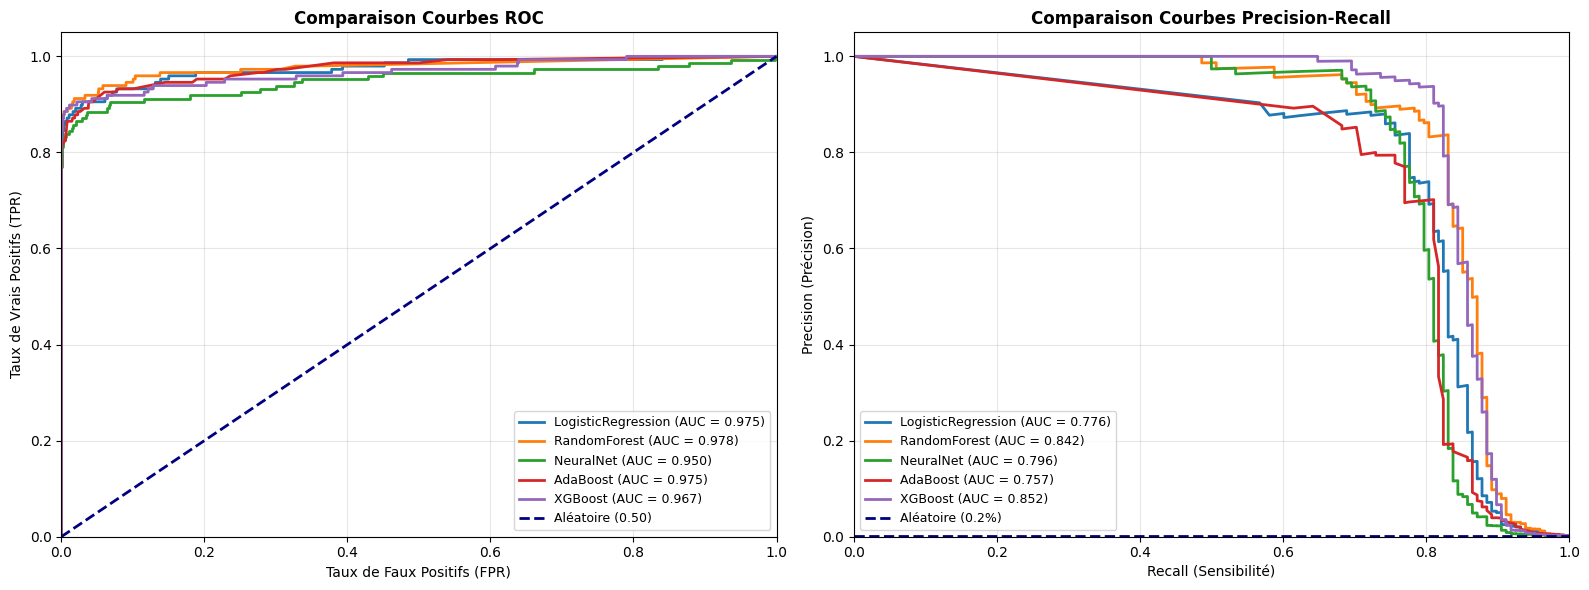

In [223]:
def plot_comparative_curves(models_dict, figsize=(16, 6)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    colors = plt.cm.tab10.colors 
    first_df = next(iter(models_dict.values()))
    baseline = first_df['y_true'].mean()

    for i, (model_name, df) in enumerate(models_dict.items()):
        
        y_true = df['y_true']
        y_pred = df['y_pred_prob']
        color = colors[i % len(colors)] 

        fpr, tpr, _ = roc_curve(y_true, y_pred)
        roc_auc = roc_auc_score(y_true, y_pred)
        clean_name = model_name.replace('_Initiale', '')
        ax1.plot(fpr, tpr, color=color, lw=2, label=f'{clean_name} (AUC = {roc_auc:.3f})')

        precision, recall, _ = precision_recall_curve(y_true, y_pred)
        pr_auc = auc(recall, precision)
        
        ax2.plot(recall, precision, color=color, lw=2, 
                 label=f'{clean_name} (AUC = {pr_auc:.3f})')

    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (0.50)')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('Taux de Faux Positifs (FPR)')
    ax1.set_ylabel('Taux de Vrais Positifs (TPR)')
    ax1.set_title('Comparaison Courbes ROC', fontweight='bold')
    ax1.legend(loc="lower right", fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', 
             label=f'Aléatoire ({baseline:.1%})')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall (Sensibilité)')
    ax2.set_ylabel('Precision (Précision)')
    ax2.set_title('Comparaison Courbes Precision-Recall', fontweight='bold')
    ax2.legend(loc="lower left", fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_comparative_curves(predi)

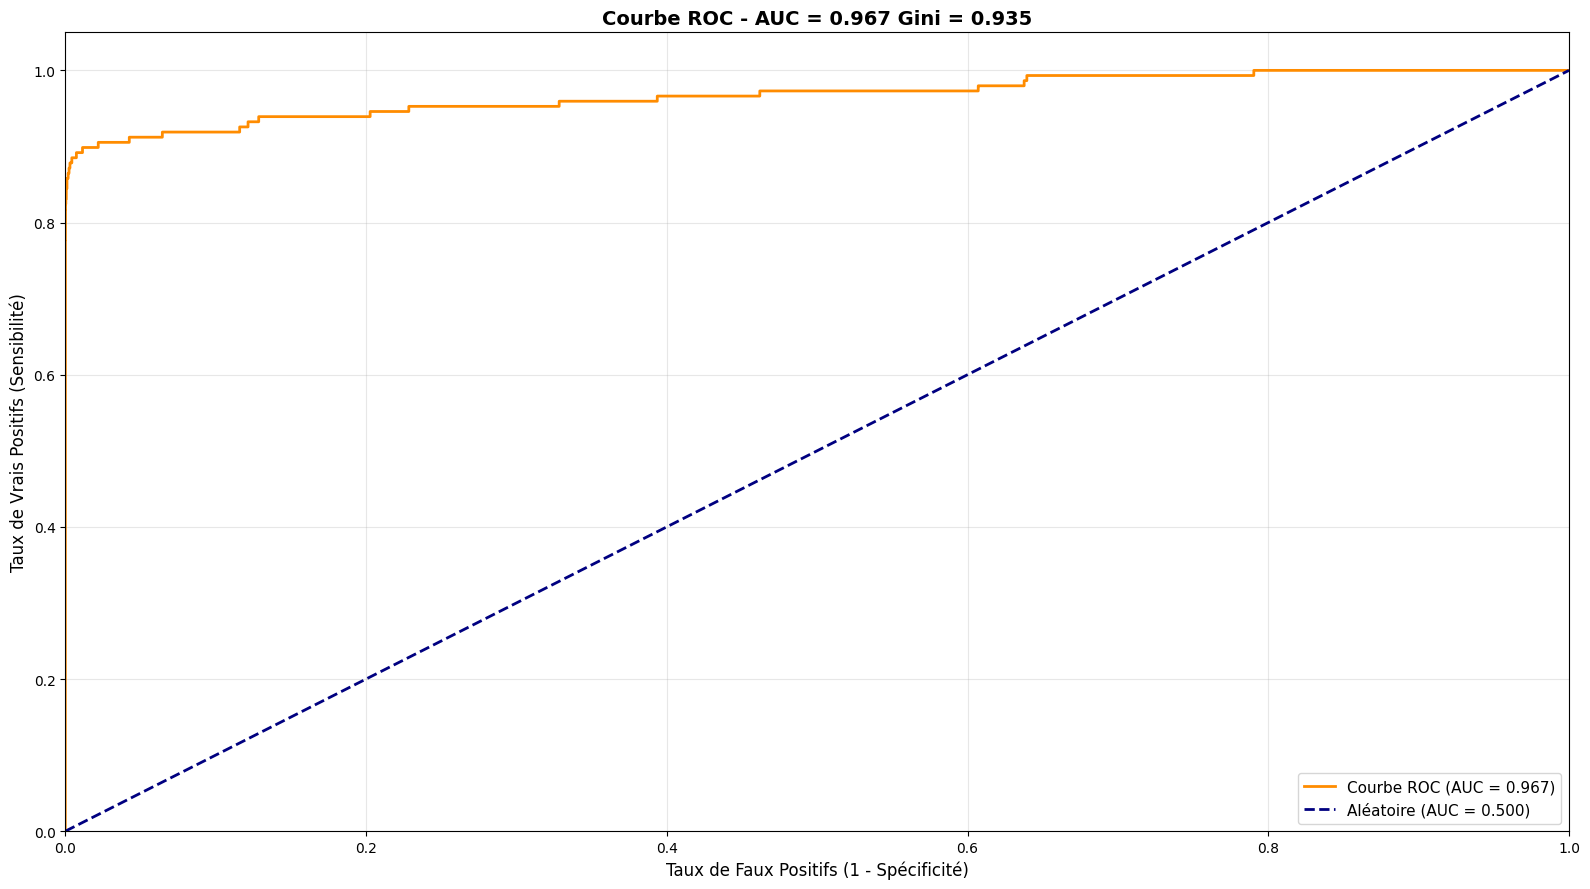

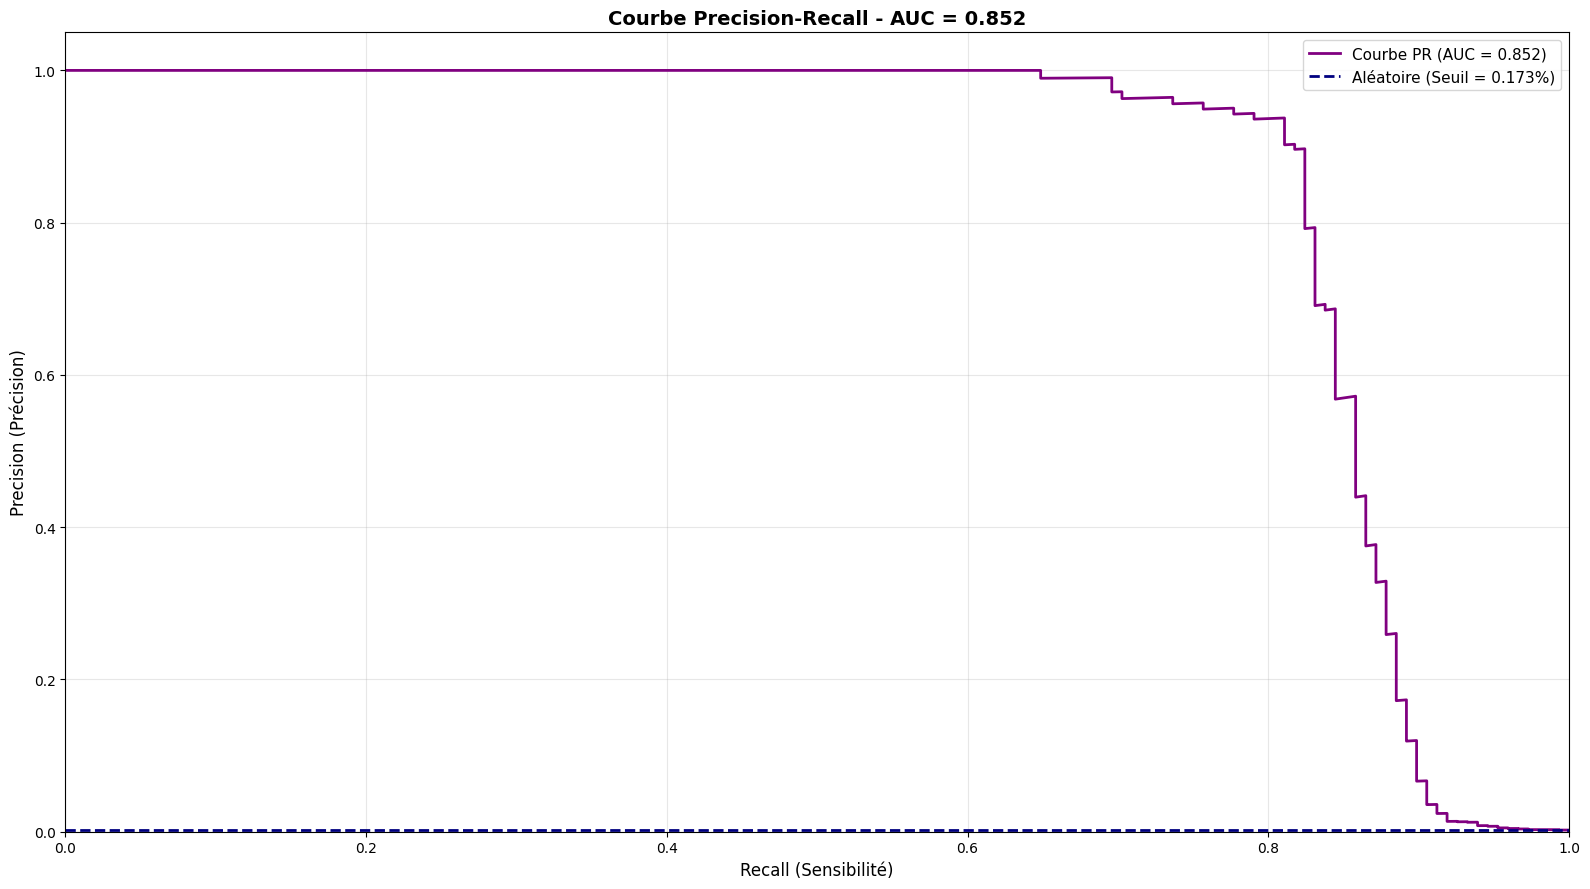

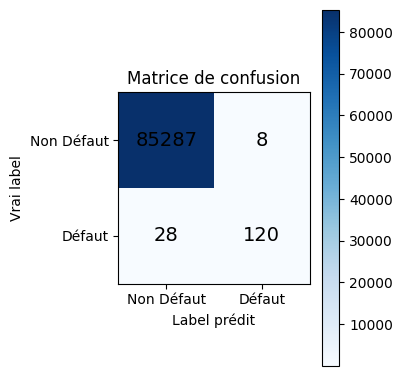

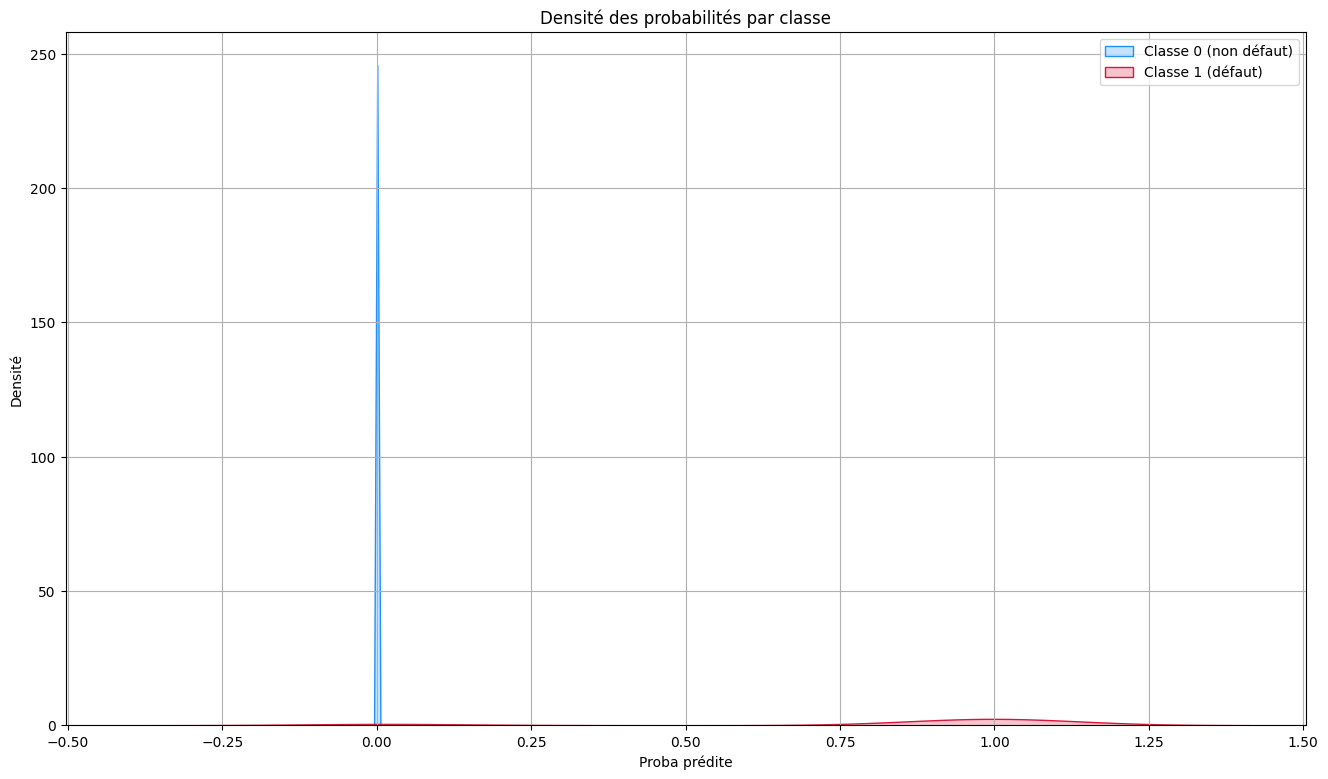

In [224]:
seuil = intersectionf(predi["XGBoost"])
visu(predi["XGBoost"], seuil)

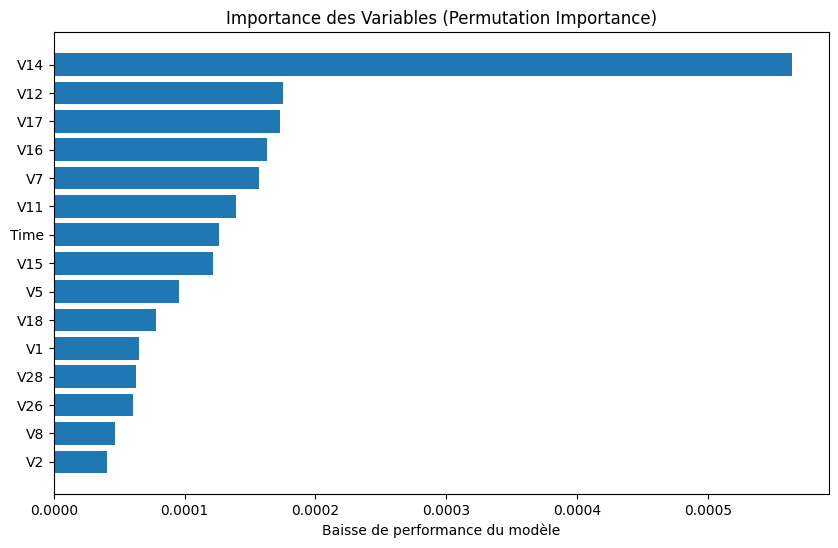

In [145]:
from sklearn.inspection import permutation_importance


result = permutation_importance(
    Recupe["smoteenn_10_90"]["XGBoost"], test_set.iloc[:,:-1], test_set.iloc[:,30], 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

df_importance = pd.DataFrame({
    'Feature': test_set.iloc[:,:-1].columns,
    'Importance': result.importances_mean,
    'Std': result.importances_std
})

df_importance = df_importance.sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'][:15], df_importance['Importance'][:15]) 
plt.xlabel("Baisse de performance du modèle")
plt.title("Importance des Variables (Permutation Importance)")
plt.gca().invert_yaxis()
plt.show()


## Cost sensitive

### Entrainement

In [ ]:
from scipy.optimize import minimize

class CostSensitiveLogitFixed:
    
    def __init__(self, cost_fp=100, cost_fn=500, alpha=0.5):
        self.cost_fp = cost_fp
        self.cost_fn = cost_fn
        self.alpha = alpha
        self.beta = None
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def _hybrid_loss(self, beta, X, y):
        p_hat = self._sigmoid(X @ beta)
        p_hat = np.clip(p_hat, 1e-15, 1 - 1e-15)
        
        # 1. Coût économique (AEC)
        cost_fn_term = y * (1 - p_hat) * self.cost_fn
        cost_fp_term = p_hat * self.cost_fp
        aec = np.mean(cost_fn_term + cost_fp_term)
        
        # 2. Cross-Entropy (log-vraisemblance négative)
        ce = -np.mean(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))
        
        # 3. Hybride
        loss = self.alpha * aec + (1 - self.alpha) * ce

        return loss
    
    def fit(self, X, y, verbose=True):
        X = np.asarray(X)
        y = np.asarray(y)
        
        X_with_intercept = np.column_stack([np.ones(len(X)), X])
        lr_init = LogisticRegression(max_iter=500, solver='lbfgs')
        lr_init.fit(X, y)
        beta_init = np.concatenate([[lr_init.intercept_[0]], lr_init.coef_[0]])
        if verbose:
            print(f"Coûts: FP={self.cost_fp}€, FN={self.cost_fn}€")
            print(f"Alpha (compromis): {self.alpha} (0=pure stats, 1=pure coût)")
            print(f"Initialisation depuis LogisticRegression...")
        result = minimize(
            fun=self._hybrid_loss,
            x0=beta_init,
            args=(X_with_intercept, y),
            method='L-BFGS-B',
            options={'maxiter': 1000, 'disp': False}
        )     
        self.beta = result.x
        p_train = self.predict_proba(X)
        if verbose:
            print(f"\n✓ Convergence: {result.success}")
            print(f"  Loss finale: {result.fun:.4f}")
            print(f"  Probas: min={p_train.min():.6f}, max={p_train.max():.6f}, mean={p_train.mean():.6f}")
            print(f"  Nb prédictions > 0.5: {(p_train > 0.5).sum()}")
        return self
    
    def predict_proba(self, X):
        X = np.asarray(X)
        X_with_intercept = np.column_stack([np.ones(len(X)), X])
        return self._sigmoid(X_with_intercept @ self.beta)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)



# Je vais ici chercher le meilleur learning rate
l1 = []
l2 = []
for i in np.logspace(-2,1,15):
    cost_investigation = 50
    model1 = CostSensitiveLogitFixed(cost_fp=cost_investigation, cost_fn=124.81450581395349, alpha=i)
    model1.fit(X_combined, y_combined)
    y_pred_proba = model1.predict_proba(X_test)
    seuil = intersectionf(pd.DataFrame({"y_true" : y_test, "y_pred_prob" : y_pred_proba}))
    y_pred = model1.predict(X_test, threshold=seuil)

    # Calcul du coût total sur test
    amounts_test = X_test.iloc[:, -1] 
    cost_total = (y_test * (1 - y_pred) * amounts_test).sum() + (y_pred * cost_investigation).sum()

    l1.append(i)
    l2.append(cost_total)


Coûts: FP=50€, FN=124.81450581395349€
Alpha (compromis): 0.01 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0068
  Probas: min=0.000000, max=1.000000, mean=0.001912
  Nb prédictions > 0.5: 242
Coûts: FP=50€, FN=124.81450581395349€
Alpha (compromis): 0.016378937069540637 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0079
  Probas: min=0.000000, max=1.000000, mean=0.001851
  Nb prédictions > 0.5: 238
Coûts: FP=50€, FN=124.81450581395349€
Alpha (compromis): 0.02682695795279726 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0097
  Probas: min=0.000000, max=1.000000, mean=0.001780
  Nb prédictions > 0.5: 236
Coûts: FP=50€, FN=124.81450581395349€
Alpha (compromis): 0.043939705607607904 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0126
  Pro

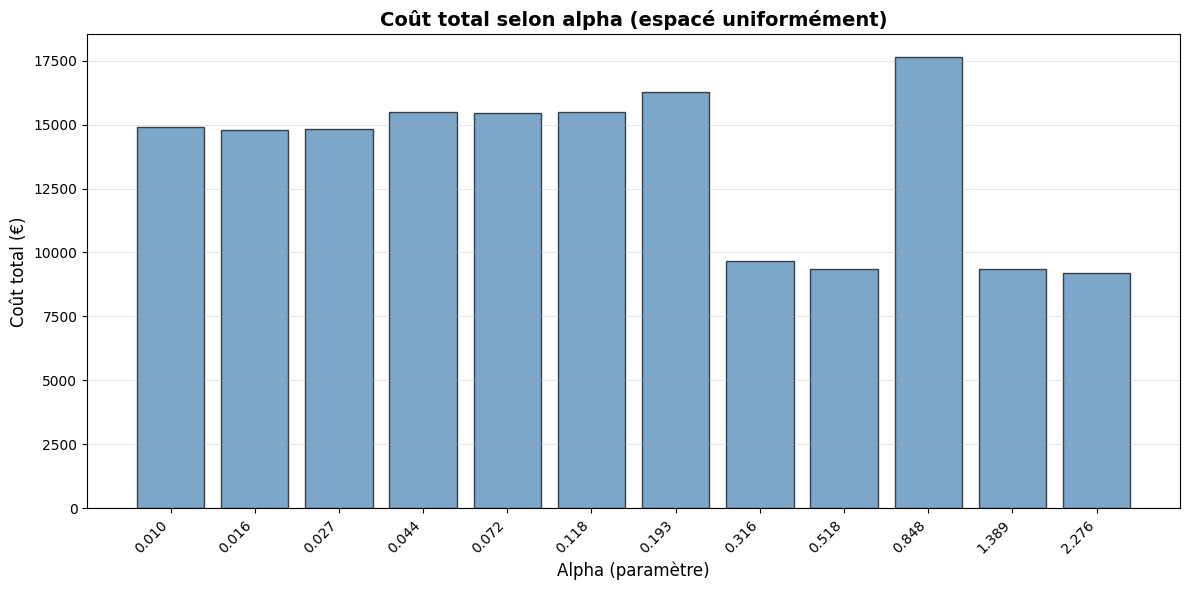

In [ ]:
alphaopti = pd.DataFrame({"Alpha":l1,"Cout":l2}).iloc[:-3,:]
plt.figure(figsize=(12, 6))
positions = np.arange(len(alphaopti))
plt.bar(positions, alphaopti['Cout'], color='steelblue', edgecolor='black', alpha=0.7)
plt.xticks(positions, [f"{alpha:.3f}" for alpha in alphaopti['Alpha']], rotation=45, ha='right')
plt.xlabel('Alpha (paramètre)', fontsize=12)
plt.ylabel('Coût total (€)', fontsize=12)
plt.title('Coût total selon alpha', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [229]:
# Je vais ici voir les couts en fonction du cout d investigation
l1 = []
l2 = []
cs = pd.DataFrame()
for i in list(range(5,75,10)):
    cost_investigation = i
    model1 = CostSensitiveLogitFixed(cost_fp=cost_investigation, cost_fn=124.81450581395349, alpha=0.518)
    model1.fit(X_combined, y_combined)
    y_pred_proba = model1.predict_proba(X_test)
    seuil = intersectionf(pd.DataFrame({"y_true" : y_test, "y_pred_prob" : y_pred_proba}))
    y_pred = model1.predict(X_test, threshold=seuil)

    # Calcul du coût total sur test
    amounts_test = X_test.iloc[:, -1] 
    cost_total = (y_test * (1 - y_pred) * amounts_test).sum() + (y_pred * cost_investigation).sum()

    l1.append(i)
    l2.append(cost_total)

    css = tout_y_a_tout(pd.DataFrame({"y_true" : y_test, "y_pred_prob" : y_pred_proba}),"CS_"+str(i), col_true='y_true', col_prob='y_pred_prob', threshold=seuil)
    cs = pd.concat([cs,pd.DataFrame(css)], axis=0)

Coûts: FP=5€, FN=124.81450581395349€
Alpha (compromis): 0.518 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0474
  Probas: min=0.000000, max=1.000000, mean=0.003439
  Nb prédictions > 0.5: 307
Coûts: FP=15€, FN=124.81450581395349€
Alpha (compromis): 0.518 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0610
  Probas: min=0.000000, max=1.000000, mean=0.002153
  Nb prédictions > 0.5: 252
Coûts: FP=25€, FN=124.81450581395349€
Alpha (compromis): 0.518 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0504
  Probas: min=0.000000, max=1.000000, mean=0.001912
  Nb prédictions > 0.5: 340
Coûts: FP=35€, FN=124.81450581395349€
Alpha (compromis): 0.518 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0600
  Probas: min=0.000000, max=1.000000, mean=0.0018

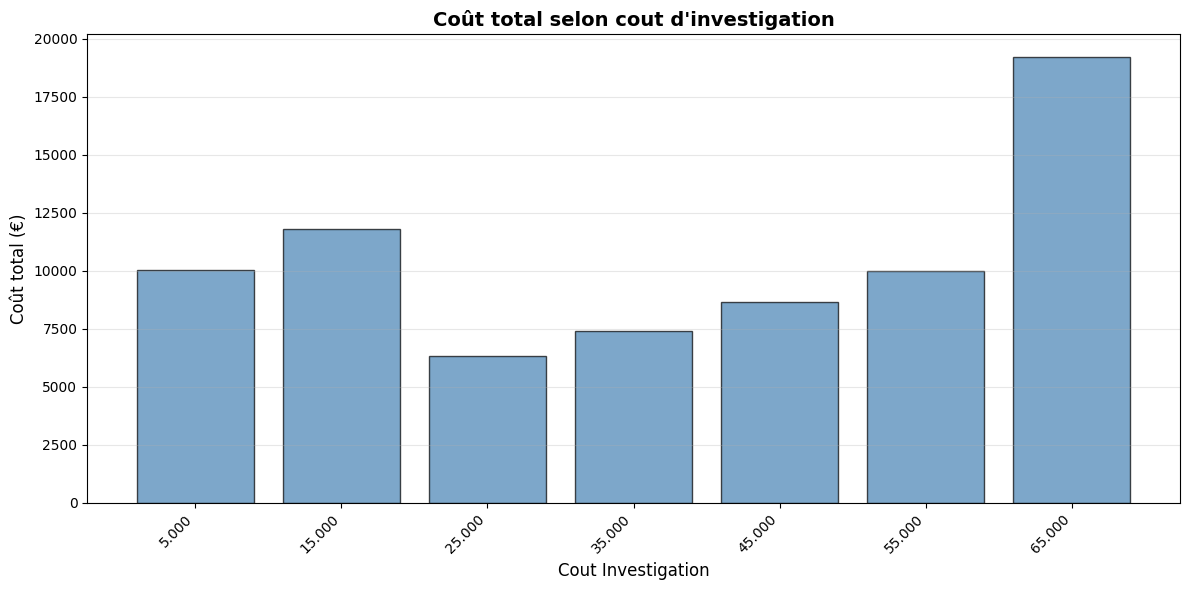

In [ ]:
alphaopti = pd.DataFrame({"Alpha":l1,"Cout":l2}).iloc[:,:]
plt.figure(figsize=(12, 6))
positions = np.arange(len(alphaopti))
plt.bar(positions, alphaopti['Cout'], color='steelblue', edgecolor='black', alpha=0.7)
plt.xticks(positions, [f"{alpha:.3f}" for alpha in alphaopti['Alpha']], rotation=45, ha='right')
plt.xlabel('Cout Investigation', fontsize=12)
plt.ylabel('Coût total (€)', fontsize=12)
plt.title("Coût total selon cout d'investigation", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Meilleur compromis pour Cout d'investigation de 50 euros

Coûts: FP=50€, FN=124.81450581395349€
Alpha (compromis): 0.518 (0=pure stats, 1=pure coût)
Initialisation depuis LogisticRegression...

✓ Convergence: True
  Loss finale: 0.0738
  Probas: min=0.000000, max=1.000000, mean=0.001768
  Nb prédictions > 0.5: 328


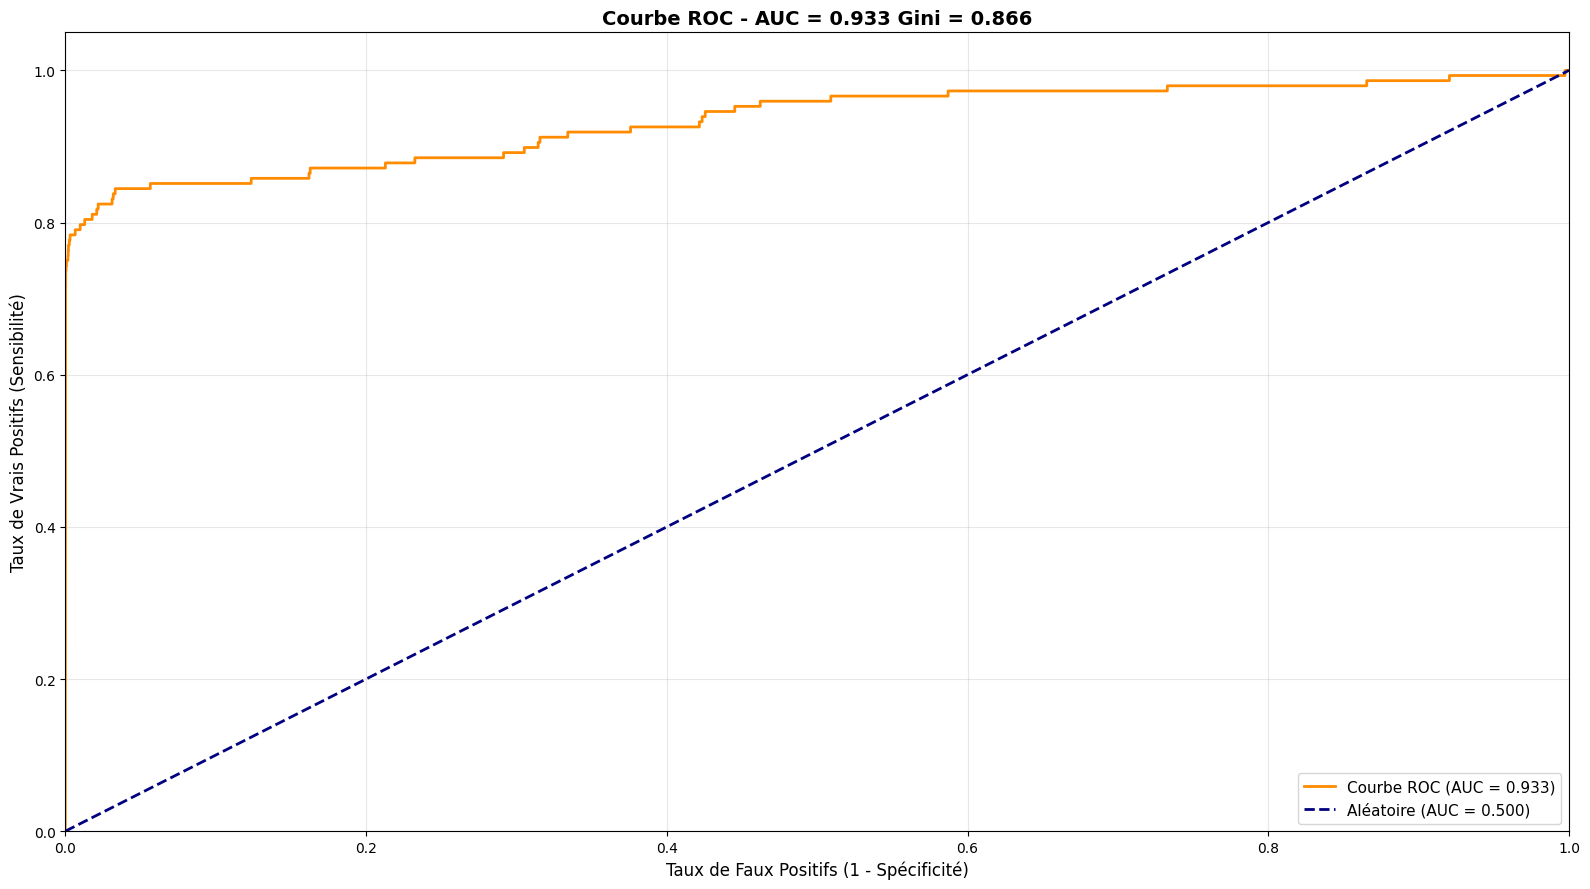

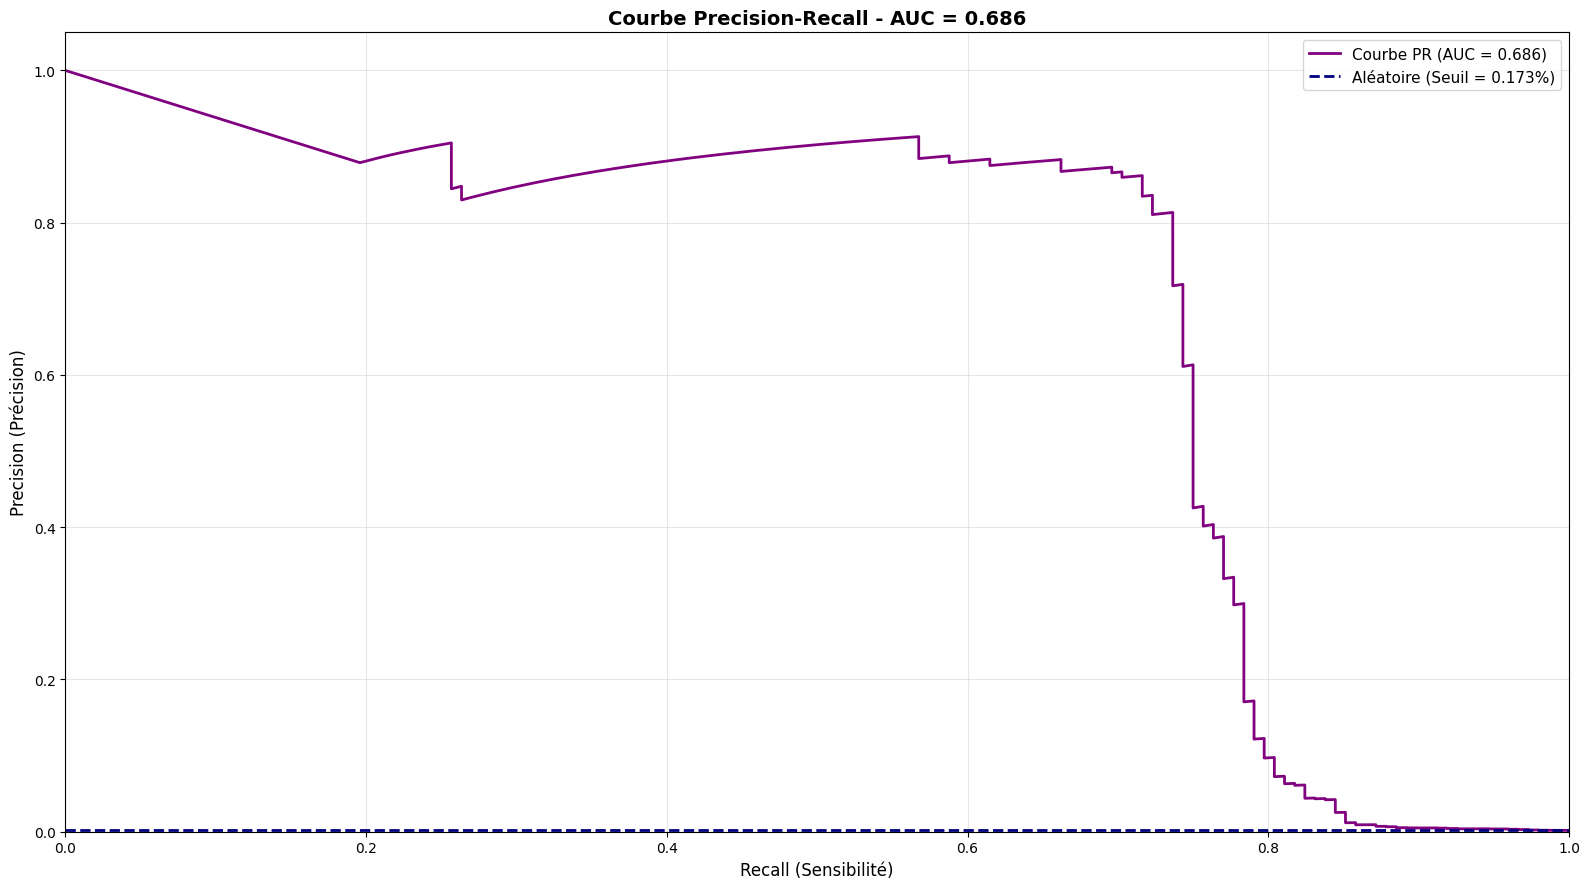

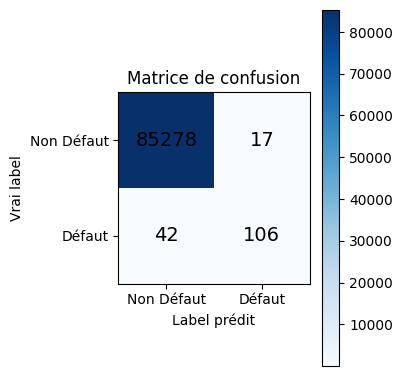

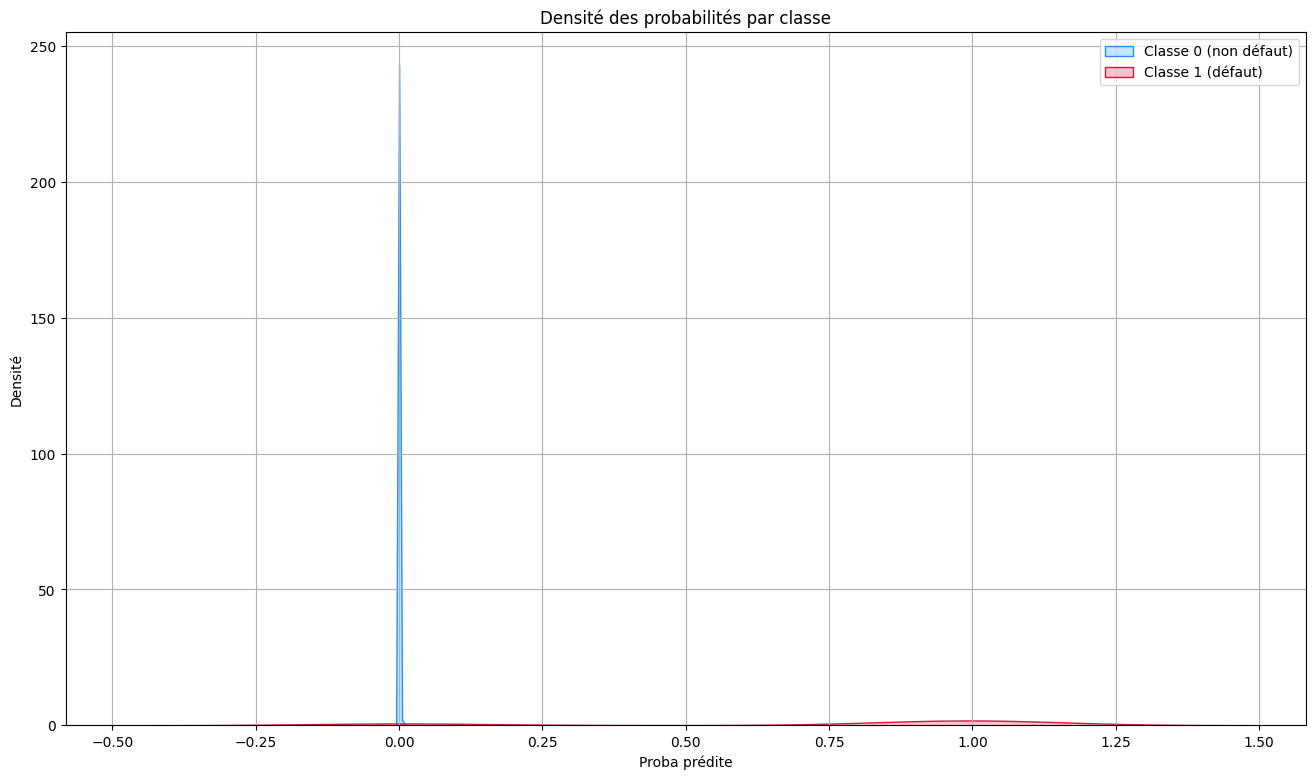

In [212]:
model1 = CostSensitiveLogitFixed(cost_fp=50, cost_fn=124.81450581395349, alpha=0.518)
model1.fit(X_combined, y_combined)
y_pred_proba = model1.predict_proba(X_test)

seuil = intersectionf(pd.DataFrame({"y_true" : y_test, "y_pred_prob" : y_pred_proba}))
visu(pd.DataFrame({"y_true" : y_test, "y_pred_prob" : y_pred_proba}), seuil)

## Detection des outliers

### HDBSCAN (800 min)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

hdbscan_model = HDBSCAN(min_cluster_size=20, metric='manhattan')
cluster_labels = hdbscan_model.fit_predict(X_scaled)
y_pred_hdbscan = (cluster_labels == -1).astype(int)

# Calcul de la matrice de confusion
cm = confusion_matrix(y, y_pred_hdbscan)

# Affichage de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit Normal', 'Prédit Fraude'],
            yticklabels=['Vrai Normal', 'Vrai Fraude'],
            cbar_kws={'label': 'Nombre d\'observations'})
plt.title('Matrice de confusion - HDBSCAN', fontsize=14, fontweight='bold')
plt.ylabel('Classe réelle', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.show()

# Analyse de la distribution des clusters
a = pd.DataFrame({"cluster": cluster_labels, "true": y})

# HDBSCAN retourne -1 pour le bruit/outliers
noise_mask = (cluster_labels == -1)

# Statistiques sur le bruit
nb_noise = noise_mask.sum()
nb_fraudes_noise = y[noise_mask].sum()
nb_fraudes_total = y.sum()

# Pourcentage de fraudes parmi le bruit
if nb_noise > 0:
    taux_fraude_noise = (nb_fraudes_noise / nb_noise) * 100
else:
    taux_fraude_noise = 0

# Pourcentage de fraudes totales capturées par le bruit (rappel)
pourcentage_fraudes_capturees = (nb_fraudes_noise / nb_fraudes_total) * 100

print(f"Nombre d'observations classées comme bruit : {nb_noise}")
print(f"Nombre de fraudes dans le bruit : {nb_fraudes_noise}")
print(f"Taux de fraudes parmi le bruit : {taux_fraude_noise:.2f}%")
print(f"Pourcentage des fraudeurs totaux trouvés dans le bruit : {pourcentage_fraudes_capturees:.2f}%")

# Pour la matrice de confusion (prédiction binaire : 1 = bruit/anomalie, 0 = normal)
cc = np.where(cluster_labels == -1, 1, 0)

latent = pd.DataFrame({"y_pred_prob": cc, "y_true": y})
confusion_matrix_df(latent, "y_pred_prob", "y_true")

print(f"\nOn remarque que dans ce qui est considéré comme du bruit par HDBSCAN, {taux_fraude_noise:.2f}% sont des fraudeurs")

# Distribution des fraudes par cluster
print("\nDistribution des fraudes par cluster :")
fraud_by_cluster = a.groupby('cluster')['true'].agg(['sum', 'count', 'mean'])
fraud_by_cluster.columns = ['Nb_fraudes', 'Nb_total', 'Taux_fraude']
fraud_by_cluster['Taux_fraude'] = fraud_by_cluster['Taux_fraude'] * 100
print(fraud_by_cluster.sort_values('Taux_fraude', ascending=False))

### ISOLATION FOREST

On remarque que 25.41% des fraudeurs se trouvent parmi les outliers détectés


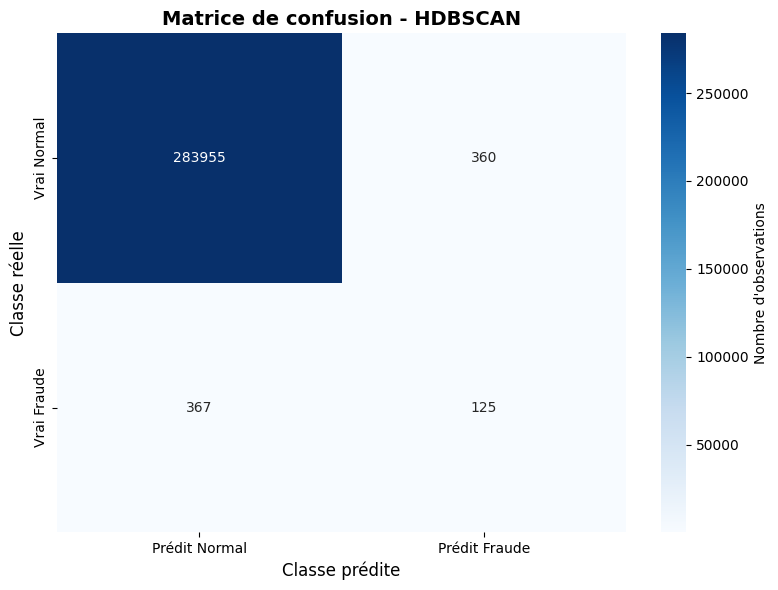

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)

iso = IsolationForest(n_estimators=100, 
                      contamination=0.0017, 
                      random_state=42, 
                      n_jobs=-1)

predi = iso.fit_predict(X_train_scaled)

# on récupère les  -1 pour qui sont designés comme outliers
outliers_mask = (predi == -1)


# Calcul du pourcentage de fraudeurs parmi les outliers
nb_fraudes_outliers = y[outliers_mask].sum()
nb_fraudes_total = y.sum()

pourcentage_fraudes_outliers = (nb_fraudes_outliers / nb_fraudes_total) * 100

print(f"On remarque que {pourcentage_fraudes_outliers:.2f}% des fraudeurs se trouvent parmi les outliers détectés")


# Calcul de la matrice de confusion
cm = confusion_matrix(y, outliers_mask)

# Affichage de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit Normal', 'Prédit Fraude'],
            yticklabels=['Vrai Normal', 'Vrai Fraude'],
            cbar_kws={'label': 'Nombre d\'observations'})
plt.title('Matrice de confusion - HDBSCAN', fontsize=14, fontweight='bold')
plt.ylabel('Classe réelle', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.show()

### Kmeans

In [ ]:
def clean_outliers_kmeans(df, n_clusters=8, contamination=0.01):
    df_numeric = df.select_dtypes(include=['number'])
    df_numeric_filled = df_numeric.fillna(df_numeric.median())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_numeric_filled)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    dist_to_center = np.min(kmeans.transform(X_scaled), axis=1)
    threshold = np.percentile(dist_to_center, 100 * (1 - contamination))
    mask_outlier = (dist_to_center > threshold)
    mask_normal = (dist_to_center <= threshold)
    df_clean = df[mask_normal].copy()
    df_outliers = df[mask_outlier].copy()
    df_outliers['Distance_Kmeans'] = dist_to_center[mask_outlier]
    print(f"=== K-MEANS CLEANING (K={n_clusters}) ===")
    print(f"Seuil de distance (Threshold) : {threshold:.4f}")
    print(f"Lignes totales    : {len(df)}")
    print(f"Lignes supprimées : {mask_outlier.sum()} ({contamination*100}%)")
    print(f"Lignes restantes  : {len(df_clean)}")
    
    return df_clean, df_outliers

df_clean_km, df_rejects_km = clean_outliers_kmeans(train_set, n_clusters=8, contamination=0.01)
print(f" {1-df_clean_km["Class"].sum()/train_set["Class"].sum()}% des fraudeurs se trouvent dans les outliers")

=== K-MEANS CLEANING (K=8) ===
Seuil de distance (Threshold) : 13.9870
Lignes totales    : 199364
Lignes supprimées : 1994 (1.0%)
Lignes restantes  : 197370
 0.49709302325581395% des fraudeurs se trouvent dans les outliers
